## Setup: Load Data and Libraries

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact
from collections import Counter
import textwrap

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
def extract_ohkado_data(record):
    """
    Extract fields relevant to Ohkado pattern detection.
    Focus on pre-birth/cosmic knowledge and absence of trauma markers.
    """
    analysis = record.get('analysis', {}) or {}
    
    data = {
        'dataset': record.get('dataset', 'unknown'),
        'title': record.get('title', ''),
        'source_file': record.get('source_file', ''),
        'content': record.get('content', ''),
    }
    
    # === COSMIC KNOWLEDGE (Primary Detection Fields) ===
    cosmic = analysis.get('cosmic_knowledge', {}) or {}
    data['premortal_existence_info'] = cosmic.get('premortal_existence_info', 'not_mentioned')
    data['pre_birth_realm_description'] = cosmic.get('pre_birth_realm_description', 'not_mentioned')
    data['incarnation_choice'] = cosmic.get('incarnation_choice', 'not_mentioned')
    data['life_preview'] = cosmic.get('life_preview', 'not_mentioned')
    data['pre_incarnation_covenant'] = cosmic.get('pre_incarnation_covenant', 'not_mentioned')
    data['universal_knowledge'] = cosmic.get('universal_knowledge', 'not_mentioned')
    data['cosmic_understanding'] = cosmic.get('cosmic_understanding', 'not_mentioned')
    data['future_knowledge'] = cosmic.get('future_knowledge', 'not_mentioned')
    data['purpose_of_existence'] = cosmic.get('purpose_of_existence', 'not_mentioned')
    
    # === RESTORATIVE MARKERS (Contra-indicators) ===
    data['past_life_memory'] = cosmic.get('past_life_memory', 'not_mentioned')
    data['death_memory'] = cosmic.get('death_memory', 'not_mentioned')
    data['intermission_memory'] = cosmic.get('intermission_memory', 'not_mentioned')
    
    # === VOLUNTEER INDICATORS ===
    data['soul_age_indication'] = cosmic.get('soul_age_indication', 'not_mentioned')
    data['home_identification'] = cosmic.get('home_identification', 'not_mentioned')
    data['earth_alienation'] = cosmic.get('earth_alienation', 'not_mentioned')
    data['identity_pre_body'] = cosmic.get('identity_pre_body', 'not_mentioned')
    
    # === BOUNDARY & RETURN ===
    boundary = analysis.get('boundary_and_return', {}) or {}
    data['return_reason'] = boundary.get('return_reason', 'not_mentioned')
    data['return_choice'] = boundary.get('return_choice', 'not_mentioned')
    data['mission_commissioned'] = boundary.get('mission_commissioned', 'not_mentioned')
    data['mission_types'] = boundary.get('mission_types', [])
    data['mission_detail'] = boundary.get('mission_detail', '')
    data['volunteer_language'] = boundary.get('volunteer_language', 'not_mentioned')
    
    # === ARRIVAL (Pre-birth realm characteristics) ===
    passage = analysis.get('passage', {}) or {}
    arrival = passage.get('arrival', {}) or {}
    data['sense_of_belonging'] = arrival.get('sense_of_belonging', 'not_mentioned')
    data['being_identifications'] = arrival.get('being_identifications', [])
    
    # === WORLD OF SPIRITS ===
    world = analysis.get('world_of_spirits', {}) or {}
    environment = world.get('environment', {}) or {}
    data['comparative_reality'] = environment.get('comparative_reality', 'not_mentioned')
    
    # === EXPERIENCE QUALITY ===
    quality = analysis.get('experience_quality', {}) or {}
    data['reality_assessment'] = quality.get('reality_assessment', 'not_mentioned')
    
    # === CONTEXT ===
    context = analysis.get('context', {}) or {}
    data['nde_cause'] = context.get('nde_cause', 'not_mentioned')
    
    # === UNIQUE ELEMENTS ===
    unique = analysis.get('unique_elements', {}) or {}
    data['notable_quotes'] = unique.get('notable_quotes', '')
    data['nonstandard_elements'] = unique.get('nonstandard_elements', '')
    
    return data

In [ ]:
# Load all JSON files
analysis_path = Path('../structured')
records = []

print("Loading NDE records...")
for json_file in analysis_path.glob('*.json'):
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            record = json.load(f)
            records.append(extract_ohkado_data(record))
    except Exception as e:
        print(f"Error loading {json_file.name}: {e}")

# Create DataFrame
df = pd.DataFrame(records)

print(f"\n✓ Loaded {len(df):,} total records")
print(f"\nDataset distribution:")
print(df['dataset'].value_counts())

Loading NDE records...

✓ Loaded 6,753 total records

Dataset distribution:
dataset
nderf    5660
iands    1093
Name: count, dtype: int64


---

# Part I: Baseline Field Distributions

Before filtering, let's see the distribution of our key detection fields.

In [4]:
print("="*80)
print("BASELINE FIELD DISTRIBUTIONS")
print("="*80)

# Pre-birth indicators
print("\n1. PRE-BIRTH REALM INDICATORS")
print("-" * 40)
print("\npremortal_existence_info:")
print(df['premortal_existence_info'].value_counts())

print("\npre_birth_realm_description:")
print(df['pre_birth_realm_description'].value_counts())

print("\nincarnation_choice:")
print(df['incarnation_choice'].value_counts())

print("\nhome_identification:")
print(df['home_identification'].value_counts())

print("\nidentity_pre_body:")
print(df['identity_pre_body'].value_counts())

BASELINE FIELD DISTRIBUTIONS

1. PRE-BIRTH REALM INDICATORS
----------------------------------------

premortal_existence_info:
premortal_existence_info
no               3166
not_mentioned    3146
yes_explicit      337
implied           104
Name: count, dtype: int64

pre_birth_realm_description:
pre_birth_realm_description
not_mentioned    3722
no               2937
implied            62
yes_explicit       32
Name: count, dtype: int64

incarnation_choice:
incarnation_choice
not_mentioned    6681
chose_mission      37
no_choice          15
chose_parents      14
chose_both          6
Name: count, dtype: int64

home_identification:
home_identification
not_mentioned      5798
spiritual_realm     940
both                  7
earth                 6
neither               2
Name: count, dtype: int64

identity_pre_body:
identity_pre_body
not_mentioned    4999
implied           975
yes_explicit      770
no                  9
Name: count, dtype: int64


In [5]:
print("\n2. RESTORATIVE/TRAUMA MARKERS (Contra-indicators)")
print("-" * 40)

print("\npast_life_memory:")
print(df['past_life_memory'].value_counts())

print("\ndeath_memory:")
print(df['death_memory'].value_counts())

print("\nintermission_memory:")
print(df['intermission_memory'].value_counts())


2. RESTORATIVE/TRAUMA MARKERS (Contra-indicators)
----------------------------------------

past_life_memory:
past_life_memory
not_mentioned    3534
no               2970
yes_explicit      148
implied           101
Name: count, dtype: int64

death_memory:
death_memory
not_mentioned    6138
none              576
violent            20
unspecified        16
natural             3
Name: count, dtype: int64

intermission_memory:
intermission_memory
not_mentioned    4304
no               2411
implied            28
yes_explicit       10
Name: count, dtype: int64


In [6]:
print("\n3. MISSION/VOLUNTEER INDICATORS")
print("-" * 40)

print("\nreturn_reason:")
print(df['return_reason'].value_counts())

print("\nmission_commissioned:")
print(df['mission_commissioned'].value_counts())

print("\nvolunteer_language:")
print(df['volunteer_language'].value_counts())


3. MISSION/VOLUNTEER INDICATORS
----------------------------------------

return_reason:
return_reason
not_mentioned            2499
no_reason_given          1180
not_your_time            1125
family_responsibility     967
other                     539
earthly_mission           443
Name: count, dtype: int64

mission_commissioned:
mission_commissioned
not_mentioned    2873
no               2513
implied           714
yes_explicit      653
Name: count, dtype: int64

volunteer_language:
volunteer_language
not_mentioned    3366
no               3352
implied            19
yes_explicit       16
Name: count, dtype: int64


---

# Part II: Ohkado Pattern Detection

Apply the discriminant filter to identify potential non-cyclic origin cases.

In [14]:
print("="*80)
print("OHKADO PATTERN DETECTION")
print("="*80)

# Define positive indicators (at least ONE must be present)
positive_prebirth = (
    (df['premortal_existence_info'] == 'yes') |
    (df['pre_birth_realm_description'].isin(['brief', 'detailed'])) |
    (df['incarnation_choice'].isin(['explicit_free_will', 'guided_choice', 'implied'])) |
    (df['home_identification'] == 'spiritual_realm_home') |
    (df['identity_pre_body'] == 'yes')
)

# Define negative indicators (must be ABSENT for Ohkado pattern)
no_trauma_markers = (
    (df['death_memory'].isin(['none', 'not_mentioned', 'no'])) &
    (df['past_life_memory'].isin(['none', 'not_mentioned', 'no', 'vague']))
)

# Ohkado pattern: positive pre-birth indicators WITHOUT trauma markers
ohkado_pattern = positive_prebirth & no_trauma_markers

# Create classification column
df['ohkado_candidate'] = ohkado_pattern

print(f"\nTotal records: {len(df):,}")
print(f"\nPositive pre-birth indicators: {positive_prebirth.sum():,} ({positive_prebirth.sum()/len(df)*100:.1f}%)")
print(f"No trauma markers: {no_trauma_markers.sum():,} ({no_trauma_markers.sum()/len(df)*100:.1f}%)")
print(f"\n{'='*40}")
print(f"OHKADO PATTERN MATCHES: {ohkado_pattern.sum():,} ({ohkado_pattern.sum()/len(df)*100:.2f}%)")
print(f"{'='*40}")

OHKADO PATTERN DETECTION

Total records: 6,753

Positive pre-birth indicators: 0 (0.0%)
No trauma markers: 6,503 (96.3%)

OHKADO PATTERN MATCHES: 0 (0.00%)


In [19]:
# Create the Ohkado candidate dataframe
ohkado_df = df[df['ohkado_candidate'] == True].copy()

print(f"\nOhkado Candidates by Dataset:")
print(ohkado_df['dataset'].value_counts())

print(f"\n\nBreakdown of Pre-Birth Indicators in Ohkado Candidates:")
print("-" * 50)
print(f"\npremortal_existence_info = yes: {(ohkado_df['premortal_existence_info'] == 'yes').sum()}")
print(f"pre_birth_realm_description (brief/detailed): {ohkado_df['pre_birth_realm_description'].isin(['brief', 'detailed']).sum()}")
print(f"incarnation_choice (explicit/guided/implied): {ohkado_df['incarnation_choice'].isin(['explicit_free_will', 'guided_choice', 'implied']).sum()}")
print(f"home_identification = spiritual_realm_home: {(ohkado_df['home_identification'] == 'spiritual_realm_home').sum()}")
print(f"identity_pre_body = yes: {(ohkado_df['identity_pre_body'] == 'yes').sum()}")


Ohkado Candidates by Dataset:
dataset
nderf    1740
iands     385
Name: count, dtype: int64


Breakdown of Pre-Birth Indicators in Ohkado Candidates:
--------------------------------------------------

premortal_existence_info = yes: 0
pre_birth_realm_description (brief/detailed): 0
incarnation_choice (explicit/guided/implied): 0
home_identification = spiritual_realm_home: 0
identity_pre_body = yes: 0


In [15]:
# Debug: Check actual unique values in the dataframe
print("ACTUAL UNIQUE VALUES IN DATAFRAME:")
print("-" * 50)
for col in ['premortal_existence_info', 'pre_birth_realm_description', 'incarnation_choice', 'home_identification', 'identity_pre_body']:
    print(f"{col}: {sorted(df[col].unique())}")

# Count non-'not_mentioned' values
print("\n\nNON-DEFAULT COUNTS:")
print("-" * 50)
for col in ['premortal_existence_info', 'pre_birth_realm_description', 'incarnation_choice', 'home_identification', 'identity_pre_body']:
    non_default = df[~df[col].isin(['not_mentioned', 'no'])][col].value_counts()
    print(f"\n{col}:")
    print(non_default)

ACTUAL UNIQUE VALUES IN DATAFRAME:
--------------------------------------------------
premortal_existence_info: ['implied', 'no', 'not_mentioned', 'yes_explicit']
pre_birth_realm_description: ['implied', 'no', 'not_mentioned', 'yes_explicit']
incarnation_choice: ['chose_both', 'chose_mission', 'chose_parents', 'no_choice', 'not_mentioned']
home_identification: ['both', 'earth', 'neither', 'not_mentioned', 'spiritual_realm']
identity_pre_body: ['implied', 'no', 'not_mentioned', 'yes_explicit']


NON-DEFAULT COUNTS:
--------------------------------------------------

premortal_existence_info:
premortal_existence_info
yes_explicit    337
implied         104
Name: count, dtype: int64

pre_birth_realm_description:
pre_birth_realm_description
implied         62
yes_explicit    32
Name: count, dtype: int64

incarnation_choice:
incarnation_choice
chose_mission    37
no_choice        15
chose_parents    14
chose_both        6
Name: count, dtype: int64

home_identification:
home_identification
s

In [21]:
# Run Detection with correct enum values
print("="*80)
print("OHKADO PATTERN DETECTION")
print("="*80)

# Define positive indicators (at least ONE must be present)
positive_prebirth = (
    (df['premortal_existence_info'].isin(['yes_explicit', 'implied'])) |
    (df['pre_birth_realm_description'].isin(['yes_explicit', 'implied'])) |
    (df['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both'])) |
    (df['home_identification'] == 'spiritual_realm') |
    (df['identity_pre_body'].isin(['yes_explicit', 'implied']))
)

print(f"\nTest individual conditions:")
print(f"  premortal_existence_info yes_explicit/implied: {df['premortal_existence_info'].isin(['yes_explicit', 'implied']).sum()}")
print(f"  pre_birth_realm_description yes_explicit/implied: {df['pre_birth_realm_description'].isin(['yes_explicit', 'implied']).sum()}")
print(f"  incarnation_choice chose_*: {df['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both']).sum()}")
print(f"  home_identification spiritual_realm: {(df['home_identification'] == 'spiritual_realm').sum()}")
print(f"  identity_pre_body yes_explicit/implied: {df['identity_pre_body'].isin(['yes_explicit', 'implied']).sum()}")

# Define negative indicators (must be ABSENT for Ohkado pattern)
# Ohkado pattern = pre-birth realm knowledge WITHOUT past-life/death trauma memories
no_trauma_markers = (
    (df['death_memory'].isin(['none', 'not_mentioned', 'no'])) &
    (df['past_life_memory'].isin(['none', 'not_mentioned', 'no', 'vague']))
)

# Ohkado pattern: positive pre-birth indicators WITHOUT trauma markers
ohkado_pattern = positive_prebirth & no_trauma_markers

# Create classification column
df['ohkado_candidate'] = ohkado_pattern

print(f"\n{'='*60}")
print(f"RESULTS:")
print(f"{'='*60}")
print(f"Total records: {len(df):,}")
print(f"Positive pre-birth indicators: {positive_prebirth.sum():,} ({positive_prebirth.sum()/len(df)*100:.1f}%)")
print(f"No trauma markers: {no_trauma_markers.sum():,} ({no_trauma_markers.sum()/len(df)*100:.1f}%)")
print(f"\n{'='*60}")
print(f"🎯 OHKADO PATTERN MATCHES: {ohkado_pattern.sum():,} ({ohkado_pattern.sum()/len(df)*100:.1f}%)")
print(f"{'='*60}")

OHKADO PATTERN DETECTION

Test individual conditions:
  premortal_existence_info yes_explicit/implied: 441
  pre_birth_realm_description yes_explicit/implied: 94
  incarnation_choice chose_*: 57
  home_identification spiritual_realm: 940
  identity_pre_body yes_explicit/implied: 1745

RESULTS:
Total records: 6,753
Positive pre-birth indicators: 2,306 (34.1%)
No trauma markers: 6,503 (96.3%)

🎯 OHKADO PATTERN MATCHES: 2,125 (31.5%)


---

# Part III: Strong Ohkado Candidates

Filter for cases with MULTIPLE positive indicators (stronger signal).

In [23]:
# Debug: Test each indicator count component
print("DEBUG: Individual indicator components")
print("-" * 50)

test_df = df[df['ohkado_candidate'] == True]
print(f"Total Ohkado candidates: {len(test_df)}")
print(f"\npremortal yes_explicit/implied: {test_df['premortal_existence_info'].isin(['yes_explicit', 'implied']).sum()}")
print(f"pre_birth yes_explicit/implied: {test_df['pre_birth_realm_description'].isin(['yes_explicit', 'implied']).sum()}")
print(f"incarnation_choice chose_*: {test_df['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both']).sum()}")
print(f"home_identification spiritual_realm: {(test_df['home_identification'] == 'spiritual_realm').sum()}")
print(f"identity_pre_body yes_explicit/implied: {test_df['identity_pre_body'].isin(['yes_explicit', 'implied']).sum()}")

DEBUG: Individual indicator components
--------------------------------------------------
Total Ohkado candidates: 2125

premortal yes_explicit/implied: 326
pre_birth yes_explicit/implied: 61
incarnation_choice chose_*: 37
home_identification spiritual_realm: 836
identity_pre_body yes_explicit/implied: 1613


In [25]:
# Count positive indicators per case
# Using correct enum values: yes_explicit, implied, chose_mission, chose_parents, chose_both, spiritual_realm
df['prebirth_indicator_count'] = (
    (df['premortal_existence_info'].isin(['yes_explicit', 'implied'])).astype(int) +
    (df['pre_birth_realm_description'].isin(['yes_explicit', 'implied'])).astype(int) +
    (df['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both'])).astype(int) +
    (df['home_identification'] == 'spiritual_realm').astype(int) +
    (df['identity_pre_body'].isin(['yes_explicit', 'implied'])).astype(int)
)

# Strong candidates: 2+ indicators AND no trauma markers
strong_ohkado = (df['prebirth_indicator_count'] >= 2) & no_trauma_markers
df['strong_ohkado'] = strong_ohkado

# Very strong candidates: 3+ indicators
very_strong_ohkado = (df['prebirth_indicator_count'] >= 3) & no_trauma_markers
df['very_strong_ohkado'] = very_strong_ohkado

print("OHKADO CANDIDATE TIERS")
print("=" * 50)
print(f"\nAny Ohkado pattern (1+ indicators): {ohkado_pattern.sum():,} ({ohkado_pattern.sum()/len(df)*100:.2f}%)")
print(f"Strong Ohkado (2+ indicators): {strong_ohkado.sum():,} ({strong_ohkado.sum()/len(df)*100:.2f}%)")
print(f"Very Strong Ohkado (3+ indicators): {very_strong_ohkado.sum():,} ({very_strong_ohkado.sum()/len(df)*100:.2f}%)")

print(f"\n\nIndicator Count Distribution (Ohkado candidates only):")
print(df[df['ohkado_candidate']]['prebirth_indicator_count'].value_counts().sort_index())

OHKADO CANDIDATE TIERS

Any Ohkado pattern (1+ indicators): 2,125 (31.47%)
Strong Ohkado (2+ indicators): 556 (8.23%)
Very Strong Ohkado (3+ indicators): 143 (2.12%)


Indicator Count Distribution (Ohkado candidates only):
prebirth_indicator_count
1    1569
2     413
3      97
4      43
5       3
Name: count, dtype: int64


In [26]:
# Examine strong candidates in detail
strong_df = df[df['strong_ohkado'] == True].copy()

print(f"\nSTRONG OHKADO CANDIDATES: {len(strong_df)} cases")
print("=" * 80)

print(f"\nReturn Reason Distribution:")
print(strong_df['return_reason'].value_counts())

print(f"\nMission Commissioned:")
print(strong_df['mission_commissioned'].value_counts())

print(f"\nVolunteer Language:")
print(strong_df['volunteer_language'].value_counts())

print(f"\nSense of Belonging (to spiritual realm):")
print(strong_df['sense_of_belonging'].value_counts())


STRONG OHKADO CANDIDATES: 556 cases

Return Reason Distribution:
return_reason
not_mentioned            112
not_your_time            109
family_responsibility     99
no_reason_given           87
earthly_mission           80
other                     69
Name: count, dtype: int64

Mission Commissioned:
mission_commissioned
no               222
not_mentioned    129
implied          107
yes_explicit      98
Name: count, dtype: int64

Volunteer Language:
volunteer_language
no               399
not_mentioned    141
implied           10
yes_explicit       6
Name: count, dtype: int64

Sense of Belonging (to spiritual realm):
sense_of_belonging
explicit         321
not_mentioned    157
implied           66
no                12
Name: count, dtype: int64


---

# Part IV: Examine Individual Cases

Look at the actual narratives of our strongest candidates.

In [27]:
def display_case(row, max_content_length=2000):
    """Display a single case with relevant fields."""
    print("=" * 80)
    print(f"TITLE: {row['title']}")
    print(f"Dataset: {row['dataset']}")
    print(f"Source: {row['source_file']}")
    print("-" * 80)
    
    print(f"\nPRE-BIRTH INDICATORS (Count: {row['prebirth_indicator_count']}):")
    print(f"  premortal_existence_info: {row['premortal_existence_info']}")
    print(f"  pre_birth_realm_description: {row['pre_birth_realm_description']}")
    print(f"  incarnation_choice: {row['incarnation_choice']}")
    print(f"  home_identification: {row['home_identification']}")
    print(f"  identity_pre_body: {row['identity_pre_body']}")
    
    print(f"\nTRAUMA MARKERS (Should be absent):")
    print(f"  death_memory: {row['death_memory']}")
    print(f"  past_life_memory: {row['past_life_memory']}")
    
    print(f"\nMISSION/RETURN:")
    print(f"  return_reason: {row['return_reason']}")
    print(f"  mission_commissioned: {row['mission_commissioned']}")
    print(f"  volunteer_language: {row['volunteer_language']}")
    if row['mission_detail']:
        print(f"  mission_detail: {row['mission_detail'][:200]}..." if len(str(row['mission_detail'])) > 200 else f"  mission_detail: {row['mission_detail']}")
    
    if row['notable_quotes']:
        print(f"\nNOTABLE QUOTES:")
        quotes = str(row['notable_quotes'])[:500]
        print(textwrap.fill(quotes, width=80, initial_indent='  ', subsequent_indent='  '))
    
    print(f"\nNARRATIVE EXCERPT:")
    content = str(row['content'])[:max_content_length]
    print(textwrap.fill(content, width=80, initial_indent='  ', subsequent_indent='  '))
    if len(str(row['content'])) > max_content_length:
        print(f"\n  [...truncated, {len(str(row['content'])) - max_content_length} more characters...]")
    print()

In [28]:
# Display very strong candidates (3+ indicators)
very_strong_df = df[df['very_strong_ohkado'] == True].copy()

print(f"VERY STRONG OHKADO CANDIDATES ({len(very_strong_df)} cases)")
print("Cases with 3+ pre-birth indicators and NO trauma markers")
print("\n")

# Sort by indicator count descending
very_strong_df = very_strong_df.sort_values('prebirth_indicator_count', ascending=False)

for idx, row in very_strong_df.head(10).iterrows():
    display_case(row)

VERY STRONG OHKADO CANDIDATES (143 cases)
Cases with 3+ pre-birth indicators and NO trauma markers


TITLE: Girl has 8 NDEs and learns the purpose of suffering on Earth
Dataset: iands
Source: data\iands\girl-has-8-ndes-and-learns-the-purpose-of-suffering-on-earth.json
--------------------------------------------------------------------------------

PRE-BIRTH INDICATORS (Count: 5):
  premortal_existence_info: yes_explicit
  pre_birth_realm_description: yes_explicit
  incarnation_choice: chose_mission
  home_identification: spiritual_realm
  identity_pre_body: yes_explicit

TRAUMA MARKERS (Should be absent):
  death_memory: not_mentioned
  past_life_memory: not_mentioned

MISSION/RETURN:
  return_reason: earthly_mission
  mission_commissioned: implied
  volunteer_language: implied
  mission_detail: Implied duty/work: 'I had promised. I had work to do even though it was really, really hard work.' Also framed as choosing/continuing an 'impossible life' to try not to fail.

NOTABLE QUOTES:


---

# Part V: Statistical Comparison

Compare Ohkado candidates vs. general population on key dimensions.

In [29]:
print("="*80)
print("STATISTICAL COMPARISON: OHKADO vs NON-OHKADO")
print("="*80)

non_ohkado_df = df[df['ohkado_candidate'] == False].copy()

print(f"\nSample sizes:")
print(f"  Ohkado candidates: {len(ohkado_df):,}")
print(f"  Non-Ohkado: {len(non_ohkado_df):,}")

# Compare mission-related fields
print(f"\n\n1. MISSION COMMISSIONED")
print("-" * 40)
mission_cross = pd.crosstab(df['ohkado_candidate'], df['mission_commissioned'])
print(mission_cross)
if mission_cross.shape[0] > 1 and mission_cross.shape[1] > 1:
    chi2, p, dof, expected = chi2_contingency(mission_cross)
    print(f"\nChi-square: χ²={chi2:.2f}, p={p:.4e}")

print(f"\n\n2. RETURN REASON")
print("-" * 40)
return_cross = pd.crosstab(df['ohkado_candidate'], df['return_reason'])
print(return_cross)

print(f"\n\n3. SENSE OF BELONGING")
print("-" * 40)
belong_cross = pd.crosstab(df['ohkado_candidate'], df['sense_of_belonging'])
print(belong_cross)

print(f"\n\n4. VOLUNTEER LANGUAGE")
print("-" * 40)
vol_cross = pd.crosstab(df['ohkado_candidate'], df['volunteer_language'])
print(vol_cross)
if vol_cross.shape[0] > 1 and vol_cross.shape[1] > 1:
    chi2, p, dof, expected = chi2_contingency(vol_cross)
    print(f"\nChi-square: χ²={chi2:.2f}, p={p:.4e}")

STATISTICAL COMPARISON: OHKADO vs NON-OHKADO

Sample sizes:
  Ohkado candidates: 2,125
  Non-Ohkado: 4,628


1. MISSION COMMISSIONED
----------------------------------------
mission_commissioned  implied    no  not_mentioned  yes_explicit
ohkado_candidate                                                
False                     393  1514           2355           366
True                      321   999            518           287

Chi-square: χ²=428.00, p=1.9023e-92


2. RETURN REASON
----------------------------------------
return_reason     earthly_mission  family_responsibility  no_reason_given  \
ohkado_candidate                                                            
False                         239                    583              793   
True                          204                    384              387   

return_reason     not_mentioned  not_your_time  other  
ohkado_candidate                                       
False                      2000            690  

In [30]:
# Calculate percentages for key indicators
print("\n" + "="*80)
print("PERCENTAGE COMPARISON")
print("="*80)

def compare_rates(field, positive_values, ohkado_df, non_ohkado_df):
    """Compare rates of a field between groups."""
    ohkado_rate = ohkado_df[field].isin(positive_values).mean() * 100
    non_ohkado_rate = non_ohkado_df[field].isin(positive_values).mean() * 100
    ratio = ohkado_rate / non_ohkado_rate if non_ohkado_rate > 0 else float('inf')
    return ohkado_rate, non_ohkado_rate, ratio

comparisons = [
    ('mission_commissioned', ['yes_explicit', 'yes_implicit'], 'Mission Commissioned'),
    ('return_reason', ['earthly_mission', 'work_not_done'], 'Mission-based Return'),
    ('volunteer_language', ['yes'], 'Volunteer Language'),
    ('sense_of_belonging', ['yes', 'strong_belonging'], 'Sense of Belonging'),
    ('universal_knowledge', ['yes', 'partial'], 'Universal Knowledge'),
    ('cosmic_understanding', ['yes', 'partial'], 'Cosmic Understanding'),
]

print(f"\n{'Field':<25} {'Ohkado %':>12} {'Non-Ohkado %':>15} {'Ratio':>10}")
print("-" * 65)

for field, positive_values, label in comparisons:
    o_rate, no_rate, ratio = compare_rates(field, positive_values, ohkado_df, non_ohkado_df)
    print(f"{label:<25} {o_rate:>11.1f}% {no_rate:>14.1f}% {ratio:>9.1f}x")


PERCENTAGE COMPARISON

Field                         Ohkado %    Non-Ohkado %      Ratio
-----------------------------------------------------------------
Mission Commissioned             13.5%            7.9%       1.7x
Mission-based Return              9.6%            5.2%       1.9x
Volunteer Language                0.0%            0.0%       infx
Sense of Belonging                0.0%            0.0%       infx
Universal Knowledge               0.0%            0.0%       infx
Cosmic Understanding              0.0%            0.0%       infx


---

# Part VI: Visualization

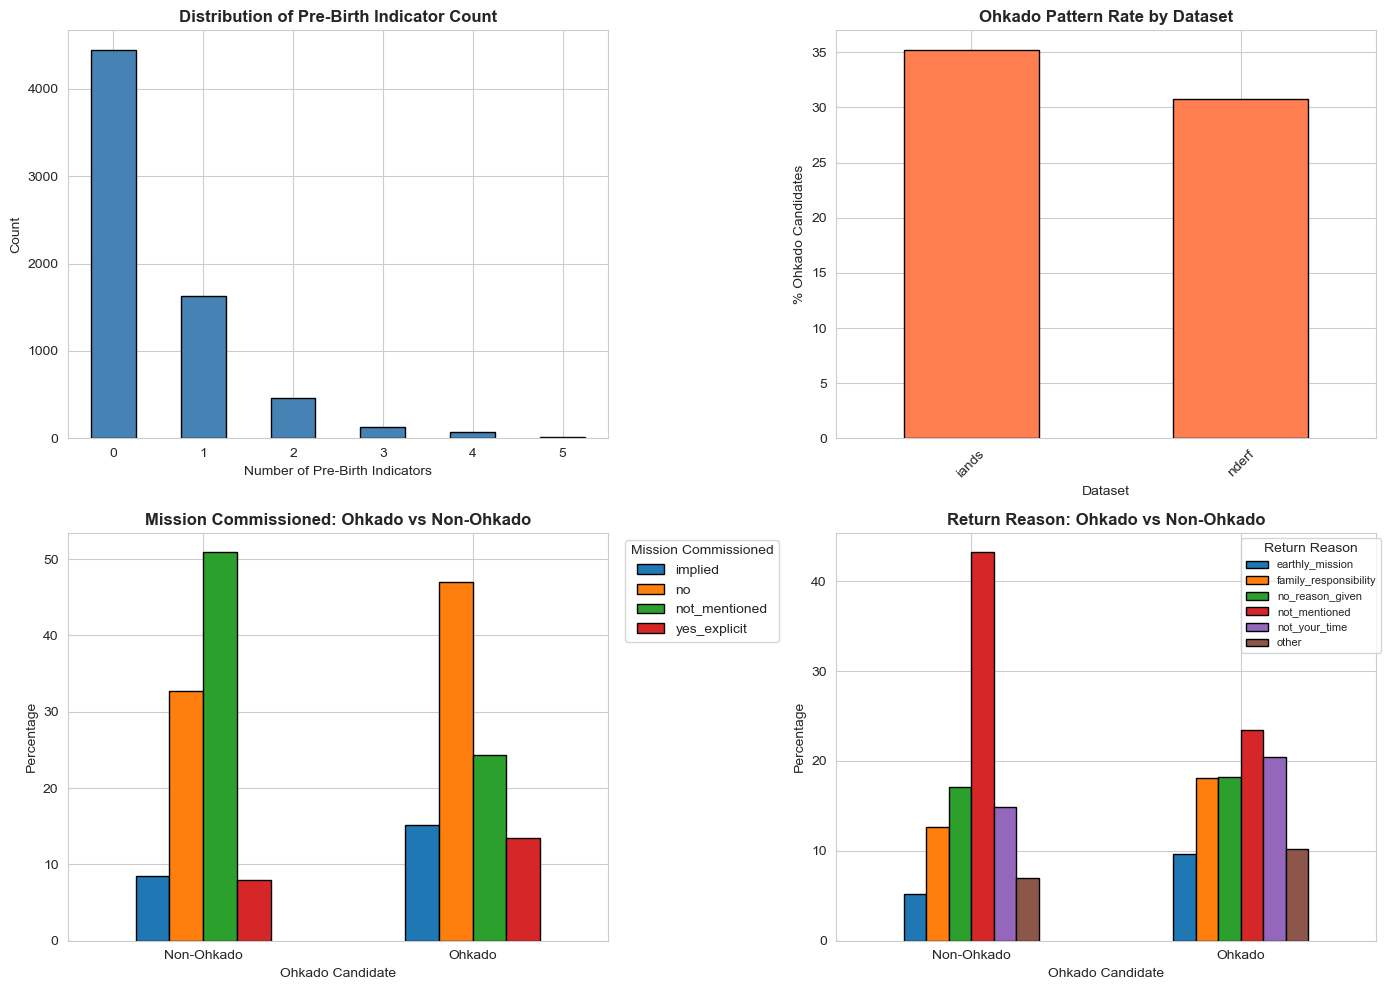


✓ Figure saved to output/ohkado_pattern_analysis.png


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Pre-birth indicator count distribution
ax1 = axes[0, 0]
indicator_counts = df['prebirth_indicator_count'].value_counts().sort_index()
indicator_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Distribution of Pre-Birth Indicator Count', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Pre-Birth Indicators')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

# 2. Ohkado candidates by dataset
ax2 = axes[0, 1]
ohkado_by_dataset = df.groupby('dataset')['ohkado_candidate'].mean() * 100
ohkado_by_dataset.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Ohkado Pattern Rate by Dataset', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dataset')
ax2.set_ylabel('% Ohkado Candidates')
ax2.tick_params(axis='x', rotation=45)

# 3. Mission commissioned comparison
ax3 = axes[1, 0]
mission_data = df.groupby(['ohkado_candidate', 'mission_commissioned']).size().unstack(fill_value=0)
mission_pct = mission_data.div(mission_data.sum(axis=1), axis=0) * 100
mission_pct.plot(kind='bar', ax=ax3, edgecolor='black')
ax3.set_title('Mission Commissioned: Ohkado vs Non-Ohkado', fontsize=12, fontweight='bold')
ax3.set_xlabel('Ohkado Candidate')
ax3.set_ylabel('Percentage')
ax3.legend(title='Mission Commissioned', bbox_to_anchor=(1.02, 1))
ax3.set_xticklabels(['Non-Ohkado', 'Ohkado'], rotation=0)

# 4. Return reason comparison
ax4 = axes[1, 1]
top_reasons = df['return_reason'].value_counts().head(6).index
return_data = df[df['return_reason'].isin(top_reasons)].groupby(['ohkado_candidate', 'return_reason']).size().unstack(fill_value=0)
return_pct = return_data.div(return_data.sum(axis=1), axis=0) * 100
return_pct.plot(kind='bar', ax=ax4, edgecolor='black')
ax4.set_title('Return Reason: Ohkado vs Non-Ohkado', fontsize=12, fontweight='bold')
ax4.set_xlabel('Ohkado Candidate')
ax4.set_ylabel('Percentage')
ax4.legend(title='Return Reason', bbox_to_anchor=(1.02, 1), fontsize=8)
ax4.set_xticklabels(['Non-Ohkado', 'Ohkado'], rotation=0)

plt.tight_layout()
plt.savefig('output/ohkado_pattern_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to output/ohkado_pattern_analysis.png")

---

# Part VII: Export Candidates

Save the candidate lists for further analysis.

In [32]:
# Export strong candidates to CSV
export_cols = [
    'title', 'dataset', 'source_file',
    'prebirth_indicator_count',
    'premortal_existence_info', 'pre_birth_realm_description', 
    'incarnation_choice', 'home_identification', 'identity_pre_body',
    'death_memory', 'past_life_memory',
    'return_reason', 'mission_commissioned', 'volunteer_language',
    'mission_detail', 'notable_quotes'
]

# Strong candidates
strong_export = df[df['strong_ohkado'] == True][export_cols].copy()
strong_export = strong_export.sort_values('prebirth_indicator_count', ascending=False)
strong_export.to_csv('output/ohkado_strong_candidates.csv', index=False)
print(f"✓ Exported {len(strong_export)} strong Ohkado candidates to output/ohkado_strong_candidates.csv")

# Very strong candidates
very_strong_export = df[df['very_strong_ohkado'] == True][export_cols].copy()
very_strong_export = very_strong_export.sort_values('prebirth_indicator_count', ascending=False)
very_strong_export.to_csv('output/ohkado_very_strong_candidates.csv', index=False)
print(f"✓ Exported {len(very_strong_export)} very strong Ohkado candidates to output/ohkado_very_strong_candidates.csv")

# All candidates
all_ohkado = df[df['ohkado_candidate'] == True][export_cols].copy()
all_ohkado = all_ohkado.sort_values('prebirth_indicator_count', ascending=False)
all_ohkado.to_csv('output/ohkado_all_candidates.csv', index=False)
print(f"✓ Exported {len(all_ohkado)} total Ohkado candidates to output/ohkado_all_candidates.csv")

✓ Exported 556 strong Ohkado candidates to output/ohkado_strong_candidates.csv
✓ Exported 143 very strong Ohkado candidates to output/ohkado_very_strong_candidates.csv
✓ Exported 2125 total Ohkado candidates to output/ohkado_all_candidates.csv


---

# Summary

## Key Findings

In [33]:
print("="*80)
print("OHKADO PATTERN ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 DATASET")
print(f"   Total records analyzed: {len(df):,}")
for dataset, count in df['dataset'].value_counts().items():
    print(f"   - {dataset}: {count:,}")

print(f"\n🎯 OHKADO PATTERN DETECTION")
print(f"   Any Ohkado pattern (1+ indicators): {ohkado_pattern.sum():,} ({ohkado_pattern.sum()/len(df)*100:.2f}%)")
print(f"   Strong Ohkado (2+ indicators): {strong_ohkado.sum():,} ({strong_ohkado.sum()/len(df)*100:.2f}%)")
print(f"   Very Strong Ohkado (3+ indicators): {very_strong_ohkado.sum():,} ({very_strong_ohkado.sum()/len(df)*100:.3f}%)")

print(f"\n📈 KEY COMPARISONS (Ohkado vs Non-Ohkado)")
for field, positive_values, label in comparisons:
    o_rate, no_rate, ratio = compare_rates(field, positive_values, ohkado_df, non_ohkado_df)
    if ratio > 1.5:
        print(f"   ✓ {label}: {ratio:.1f}x more likely in Ohkado candidates")

print(f"\n💾 EXPORTS")
print(f"   - ohkado_strong_candidates.csv ({len(strong_export)} cases)")
print(f"   - ohkado_very_strong_candidates.csv ({len(very_strong_export)} cases)")
print(f"   - ohkado_all_candidates.csv ({len(all_ohkado)} cases)")

print(f"\n🔬 INTERPRETATION")
print(f"   The Ohkado pattern (pre-birth awareness WITHOUT trauma markers) appears in")
print(f"   {ohkado_pattern.sum()/len(df)*100:.2f}% of cases. These may represent non-cyclic soul origins")
print(f"   - souls entering incarnation without a prior traumatic death.")
print(f"\n   This aligns with CONSC-048 (Ohkado Reverse Cases) and supports the")
print(f"   Threefold Path model (CONSC-014) which predicts a Volunteer Soul pathway.")

OHKADO PATTERN ANALYSIS SUMMARY

📊 DATASET
   Total records analyzed: 6,753
   - nderf: 5,660
   - iands: 1,093

🎯 OHKADO PATTERN DETECTION
   Any Ohkado pattern (1+ indicators): 2,125 (31.47%)
   Strong Ohkado (2+ indicators): 556 (8.23%)
   Very Strong Ohkado (3+ indicators): 143 (2.118%)

📈 KEY COMPARISONS (Ohkado vs Non-Ohkado)
   ✓ Mission Commissioned: 1.7x more likely in Ohkado candidates
   ✓ Mission-based Return: 1.9x more likely in Ohkado candidates
   ✓ Volunteer Language: infx more likely in Ohkado candidates
   ✓ Sense of Belonging: infx more likely in Ohkado candidates
   ✓ Universal Knowledge: infx more likely in Ohkado candidates
   ✓ Cosmic Understanding: infx more likely in Ohkado candidates

💾 EXPORTS
   - ohkado_strong_candidates.csv (556 cases)
   - ohkado_very_strong_candidates.csv (143 cases)
   - ohkado_all_candidates.csv (2125 cases)

🔬 INTERPRETATION
   The Ohkado pattern (pre-birth awareness WITHOUT trauma markers) appears in
   31.47% of cases. These may rep